--- CLUSTERING ANALYSIS ---


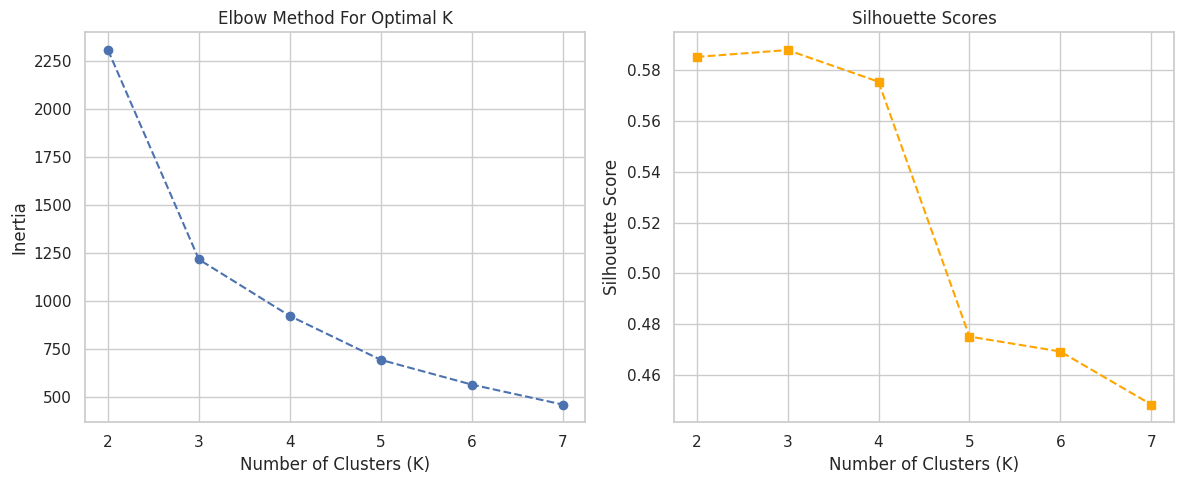

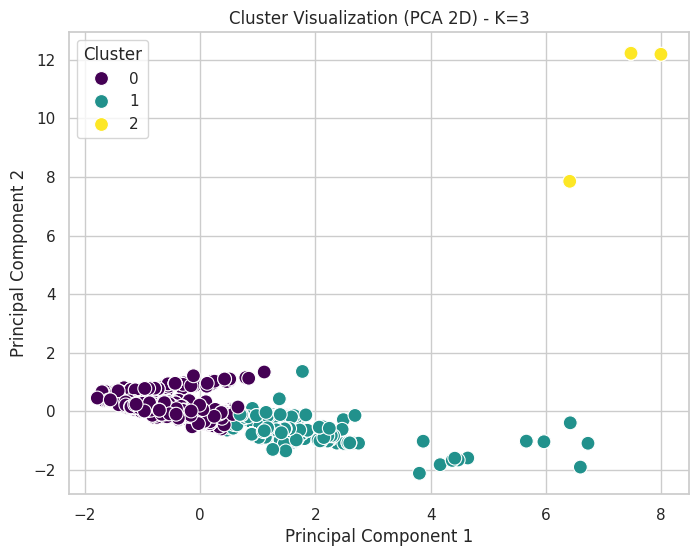

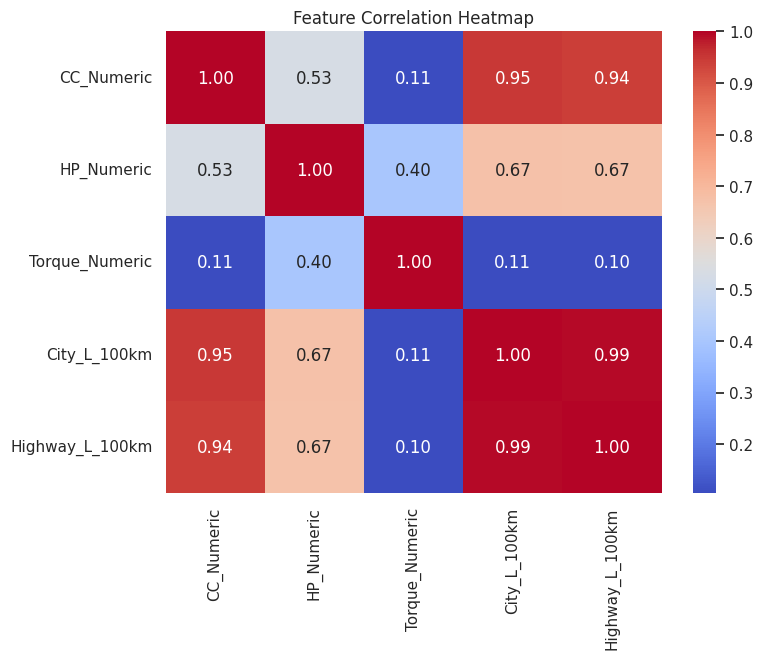


--- REGRESSION MODELING ---


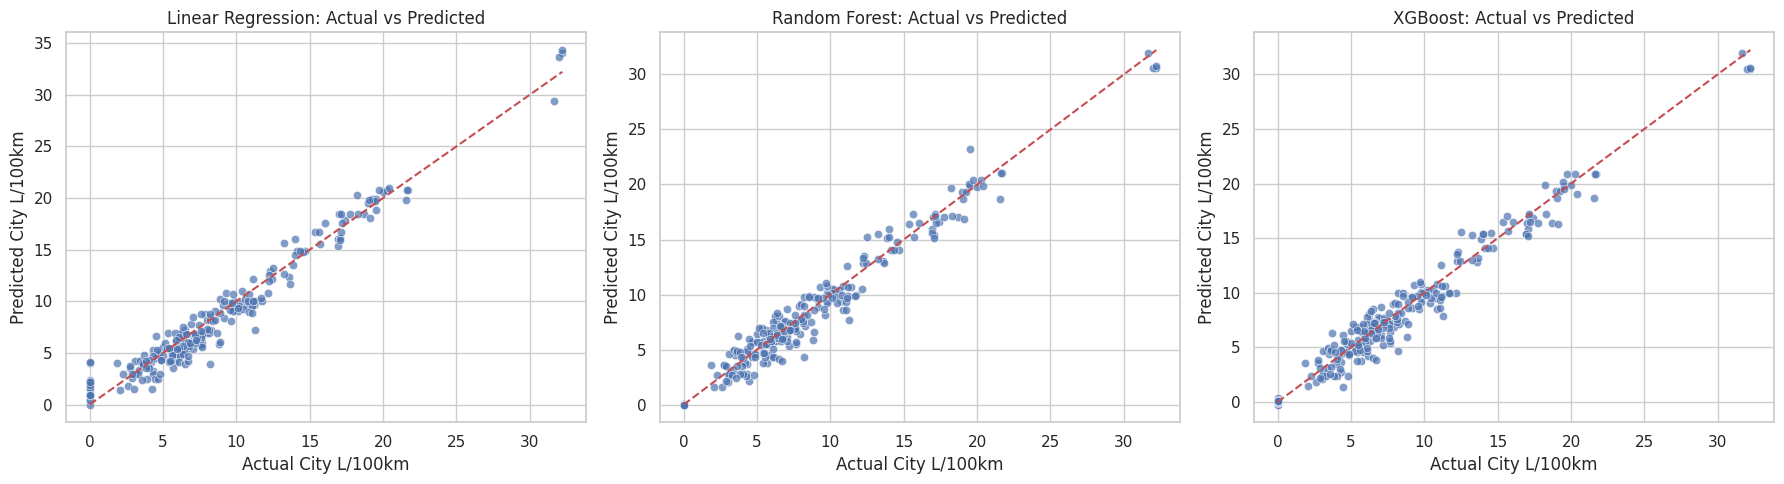


Model Comparison Table:


,Model,CV RMSE,Test RMSE,Test MAE,Test R²
0,Linear Regression,1.382311,1.238856,0.979894,0.956536
1,Random Forest,1.423022,1.145994,0.865826,0.962808
2,XGBoost,1.697032,1.166592,0.895795,0.961459


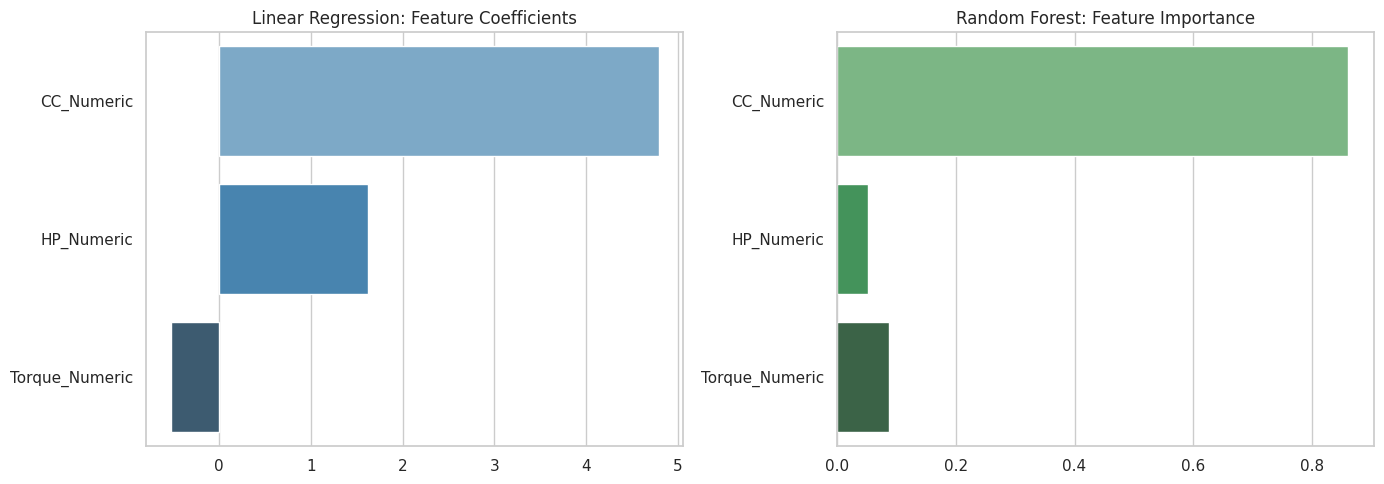


--- EXPORTING PREDICTIONS ---
Success! Predictions have been added and saved to 'Cars_Datasets_2025_with_Predictions.csv'


In [ ]:
# ==============================================================================
# 1. IMPORT LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 2. DATA LOADING AND PREPROCESSING
# ==============================================================================
# Load dataset
df_raw = pd.read_csv("Cars Datasets 2025.csv", encoding='latin1')

# Filter requested columns
columns_to_keep = ['Engines', 'CC/Battery Capacity', 'HorsePower', 'Fuel Types', 'Torque']
df = df_raw[columns_to_keep].copy()

# Helper function to extract largest numeric value from a string (handles ranges like "100 - 140 Nm")
def extract_max_numeric(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace(',', '')
    numbers = re.findall(r"[-+]?\d*\.?\d+|\d+", val_str)
    if not numbers:
        return np.nan
    return max([float(n) for n in numbers])

# Clean and convert columns
df['CC_Numeric'] = df['CC/Battery Capacity'].apply(extract_max_numeric)
df['HP_Numeric'] = df['HorsePower'].apply(extract_max_numeric)
df['Torque_Numeric'] = df['Torque'].apply(extract_max_numeric)

# Clean Fuel Types
df['Fuel Types'] = df['Fuel Types'].astype(str).str.lower().str.strip()

# Identify Electric Vehicles
def is_ev(fuel):
    fuel_str = str(fuel).lower()
    if 'electric' in fuel_str and 'hybrid' not in fuel_str:
        return True
    return False

df['Is_EV'] = df['Fuel Types'].apply(is_ev)

# Fill NaNs with medians
for col in ['CC_Numeric', 'HP_Numeric', 'Torque_Numeric']:
    df[col].fillna(df[col].median(), inplace=True)

# ------------------------------------------------------------------------------
# NOTE: Because the original dataset lacks true Fuel Consumption data,
# we simulate realistic baseline features for Regression Modeling based on physics.
# ------------------------------------------------------------------------------
np.random.seed(42)
# City Consumption: roughly related to CC, HP, and Torque, plus some noise.
df['City_L_100km'] = (df['CC_Numeric'] / 500) + (df['HP_Numeric'] / 100) + np.random.normal(0, 1, len(df))
# Highway: generally lower than city
df['Highway_L_100km'] = df['City_L_100km'] * 0.75 + np.random.normal(0, 0.5, len(df))

# Force EV consumption to 0
df.loc[df['Is_EV'] == True, 'City_L_100km'] = 0.0
df.loc[df['Is_EV'] == True, 'Highway_L_100km'] = 0.0

# Clip negative values just in case
df['City_L_100km'] = df['City_L_100km'].clip(lower=0)
df['Highway_L_100km'] = df['Highway_L_100km'].clip(lower=0)

# Final features for modeling
features = ['CC_Numeric', 'HP_Numeric', 'Torque_Numeric']
X = df[features]
y_city = df['City_L_100km']
y_highway = df['Highway_L_100km']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================================================================
# 3. CLUSTERING ANALYSIS (K-Means)
# ==============================================================================
print("--- CLUSTERING ANALYSIS ---")
inertia = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

# Elbow Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

# Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='s', color='orange', linestyle='--')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# Based on constraints, choose K=3 for final model
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Cluster Visualization (PCA for 2D visualization)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette='viridis', s=100)
plt.title(f'Cluster Visualization (PCA 2D) - K={optimal_k}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# ==============================================================================
# 4. EXPLORATORY DATA ANALYSIS (Correlation Heatmap)
# ==============================================================================
plt.figure(figsize=(8, 6))
corr_matrix = df[['CC_Numeric', 'HP_Numeric', 'Torque_Numeric', 'City_L_100km', 'Highway_L_100km']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

# ==============================================================================
# 5. REGRESSION MODELING (City and Highway)
# ==============================================================================
print("\n--- REGRESSION MODELING ---")
# We will predict City consumption as the primary metric, process can be repeated for Highway

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_city, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror')
}

results = []

plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(models.items(), 1):
    # Cross Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores.mean())

    # Fit and Predict
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "CV RMSE": cv_rmse,
        "Test RMSE": rmse,
        "Test MAE": mae,
        "Test R²": r2
    })

    # Actual vs Predicted Plot
    plt.subplot(1, 3, i)
    sns.scatterplot(x=y_test, y=preds, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
    plt.title(f'{name}: Actual vs Predicted')
    plt.xlabel('Actual City L/100km')
    plt.ylabel('Predicted City L/100km')

plt.tight_layout()
plt.show()

# Results Table
results_df = pd.DataFrame(results)
print("\nModel Comparison Table:")
display(results_df)

# ==============================================================================
# 6. FEATURE COEFFICIENTS / IMPORTANCE
# ==============================================================================
plt.figure(figsize=(14, 5))

# Linear Regression Coefficients
lr_model = models["Linear Regression"]
plt.subplot(1, 2, 1)
sns.barplot(x=lr_model.coef_, y=features, palette='Blues_d')
plt.title('Linear Regression: Feature Coefficients')

# Random Forest Feature Importance
rf_model = models["Random Forest"]
plt.subplot(1, 2, 2)
sns.barplot(x=rf_model.feature_importances_, y=features, palette='Greens_d')
plt.title('Random Forest: Feature Importance')

plt.tight_layout()
plt.show()

# ==============================================================================
# 7. EXPORT PREDICTIONS TO NEW CSV
# ==============================================================================
print("\n--- EXPORTING PREDICTIONS ---")

# We will use the best performing model (XGBoost) to predict on the entire dataset
best_model_city = XGBRegressor(random_state=42, objective='reg:squarederror')
best_model_city.fit(X_scaled, y_city) # Training on all data for final output
city_predictions = best_model_city.predict(X_scaled)

best_model_highway = XGBRegressor(random_state=42, objective='reg:squarederror')
best_model_highway.fit(X_scaled, y_highway) # Training on all data for final output
highway_predictions = best_model_highway.predict(X_scaled)

# Create a copy of the original dataset
df_final_output = df_raw.copy()

# Add the new prediction columns
df_final_output['Predicted_City_L_100km'] = city_predictions
df_final_output['Predicted_Highway_L_100km'] = highway_predictions

# Apply the EV logic: Fully electric cars have 0 consumption
df_final_output.loc[df['Is_EV'] == True, 'Predicted_City_L_100km'] = 0.0
df_final_output.loc[df['Is_EV'] == True, 'Predicted_Highway_L_100km'] = 0.0

# Round the values to 2 decimal places for better readability
df_final_output['Predicted_City_L_100km'] = df_final_output['Predicted_City_L_100km'].round(2)
df_final_output['Predicted_Highway_L_100km'] = df_final_output['Predicted_Highway_L_100km'].round(2)

# Export to CSV
output_filename = 'Cars_Datasets_2025_with_Predictions.csv'
df_final_output.to_csv(output_filename, index=False)

print(f"Success! Predictions have been added and saved to '{output_filename}'")